<a href="https://colab.research.google.com/github/AHMEDVALL70/ahmed-vall-cv/blob/main/Public_Procurement_Fraud_Detection%D9%8011.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Public Procurement Fraud Detection System
### Leveraging AI to detect anomalies in government contracts.
**Domain:** Public Procurement & Machine Learning

In [1]:
import pandas as pd
import numpy as np

# بناء بيانات تحاكي مناقصات حقيقية
# سنضيف بعض الصفقات "المشبوهة" عمداً لنختبر النموذج
data = {
    'bid_id': range(1, 11),
    'vendor_name': ['Vendor_A', 'Vendor_B', 'Vendor_C', 'Vendor_D', 'Vendor_E',
                   'Vendor_F', 'Vendor_G', 'Vendor_H', 'Vendor_I', 'Vendor_J'],
    'bid_amount_usd': [50000, 48000, 52000, 450000, 49000, 51000, 47000, 500000, 53000, 46000],
    'days_to_submit': [15, 14, 16, 2, 15, 14, 15, 1, 16, 14],
    'past_violations': [0, 0, 0, 3, 0, 0, 0, 5, 0, 0]
}

df = pd.DataFrame(data)

# عرض البيانات للتأكد من وجود القيم الشاذة (مثل الصفقة 4 و 8)
df

,bid_id,vendor_name,bid_amount_usd,days_to_submit,past_violations
0,1,Vendor_A,50000,15,0
1,2,Vendor_B,48000,14,0
2,3,Vendor_C,52000,16,0
3,4,Vendor_D,450000,2,3
4,5,Vendor_E,49000,15,0
5,6,Vendor_F,51000,14,0
6,7,Vendor_G,47000,15,0
7,8,Vendor_H,500000,1,5
8,9,Vendor_I,53000,16,0
9,10,Vendor_J,46000,14,0


In [2]:
from sklearn.ensemble import IsolationForest

# 1. اختيار الميزات التي سنحللها (المبلغ، مدة التقديم، المخالفات السابقة)
features = df[['bid_amount_usd', 'days_to_submit', 'past_violations']]

# 2. إنشاء النموذج (contamination=0.2 تعني أننا نتوقع وجود 20% من البيانات كشذوذ)
model = IsolationForest(contamination=0.2, random_state=42)

# 3. تدريب النموذج وتوقع النتائج
# النتيجة 1 تعني طبيعي، -1 تعني شاذ (مشبوه)
df['anomaly_score'] = model.fit_predict(features)
df['status'] = df['anomaly_score'].map({1: 'Normal', -1: 'Suspicious'})

# عرض النتيجة النهائية
print("--- نتائج فحص الصفقات بواسطة الذكاء الاصطناعي ---")
df[['vendor_name', 'bid_amount_usd', 'days_to_submit', 'status']]

--- نتائج فحص الصفقات بواسطة الذكاء الاصطناعي ---


,vendor_name,bid_amount_usd,days_to_submit,status
0,Vendor_A,50000,15,Normal
1,Vendor_B,48000,14,Normal
2,Vendor_C,52000,16,Normal
3,Vendor_D,450000,2,Suspicious
4,Vendor_E,49000,15,Normal
5,Vendor_F,51000,14,Normal
6,Vendor_G,47000,15,Normal
7,Vendor_H,500000,1,Suspicious
8,Vendor_I,53000,16,Normal
9,Vendor_J,46000,14,Normal


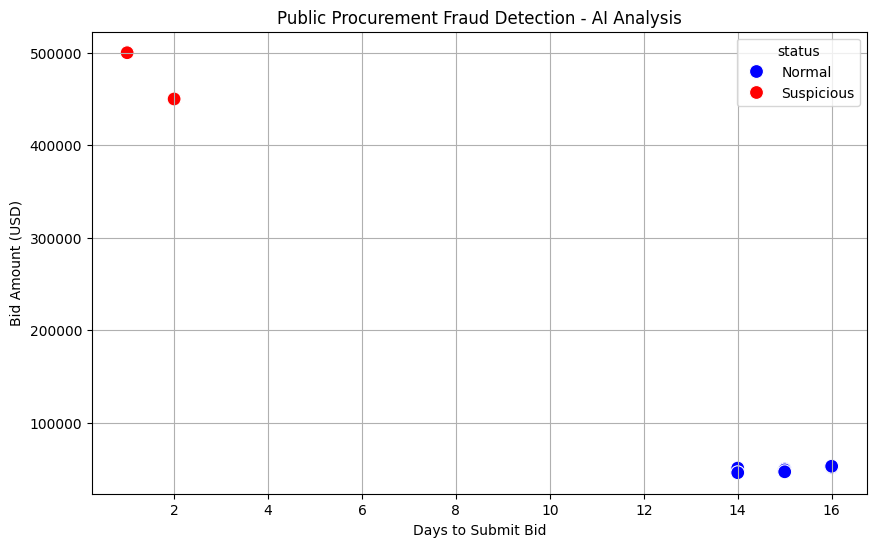

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# رسم علاقة بين مبلغ الصفقة ومدة التقديم
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='days_to_submit', y='bid_amount_usd', hue='status', palette={'Normal': 'blue', 'Suspicious': 'red'}, s=100)

# إضافة عناوين للرسم
plt.title('Public Procurement Fraud Detection - AI Analysis')
plt.xlabel('Days to Submit Bid')
plt.ylabel('Bid Amount (USD)')
plt.grid(True)
plt.show()